In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV

In [4]:
df = pd.read_csv(r"/Users/siddhu/Desktop/Programs/Machine Learning/Ex3/introvert or extrovert.csv")
print(df.head())

   Time_spent_Alone Stage_fear  Social_event_attendance  Going_outside  \
0               4.0         No                      4.0              6   
1               9.0        Yes                      0.0              0   
2               9.0        Yes                      1.0              2   
3               0.0         No                      6.0              7   
4               3.0         No                      9.0              4   

  Drained_after_socializing  Friends_circle_size  Post_frequency Personality  
0                        No                 13.0             5.0   Extrovert  
1                       Yes                  0.0             3.0   Introvert  
2                       Yes                  5.0             2.0   Introvert  
3                        No                 14.0             8.0   Extrovert  
4                        No                  8.0             5.0   Extrovert  


In [5]:
print(df.describe())

       Time_spent_Alone  Social_event_attendance  Going_outside  \
count       2900.000000              2900.000000    2900.000000   
mean           4.505816                 3.963354       3.000000   
std            3.441180                 2.872608       2.221597   
min            0.000000                 0.000000       0.000000   
25%            2.000000                 2.000000       1.000000   
50%            4.000000                 3.963354       3.000000   
75%            7.000000                 6.000000       5.000000   
max           11.000000                10.000000       7.000000   

       Friends_circle_size  Post_frequency  
count          2900.000000     2900.000000  
mean              6.268863        3.564727  
std               4.232340        2.893587  
min               0.000000        0.000000  
25%               3.000000        1.000000  
50%               5.000000        3.000000  
75%              10.000000        6.000000  
max              15.000000       10.

In [6]:
print(df.isnull().sum())

Time_spent_Alone             0
Stage_fear                   0
Social_event_attendance      0
Going_outside                0
Drained_after_socializing    0
Friends_circle_size          0
Post_frequency               0
Personality                  0
dtype: int64


In [7]:
df['Personality'].value_counts()
df['Personality'].value_counts(normalize=True) * 100

Personality
Extrovert    51.413793
Introvert    48.586207
Name: proportion, dtype: float64

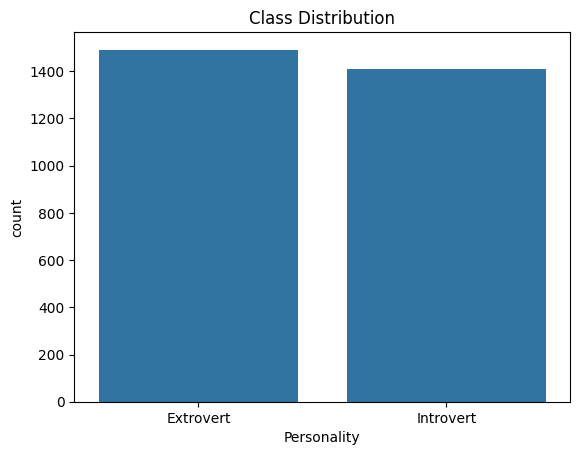

In [8]:
sns.countplot(x='Personality', data=df)
plt.title("Class Distribution")
plt.show()

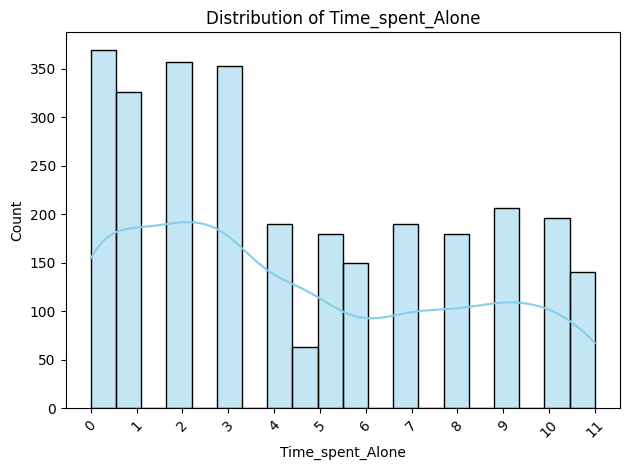

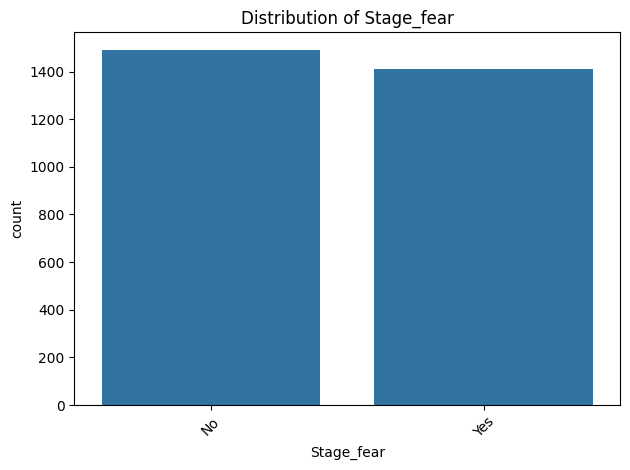

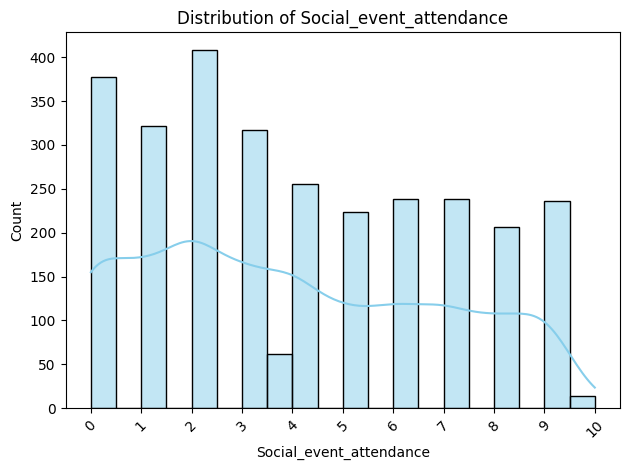

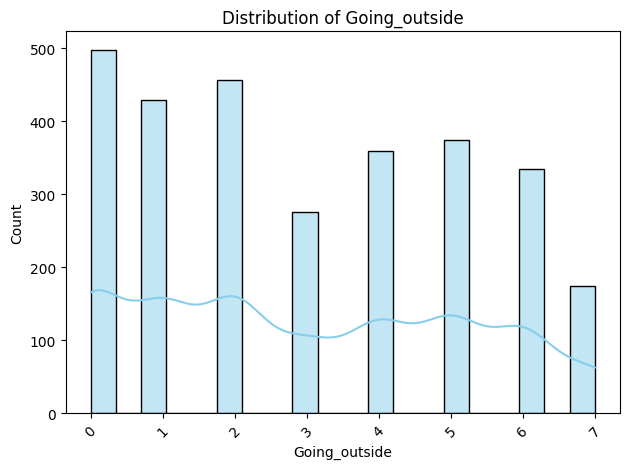

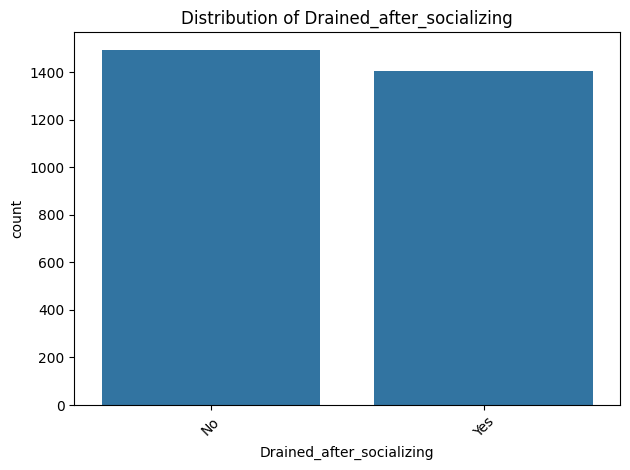

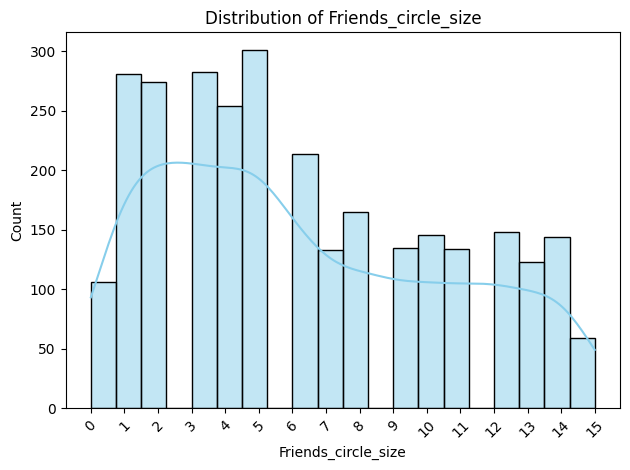

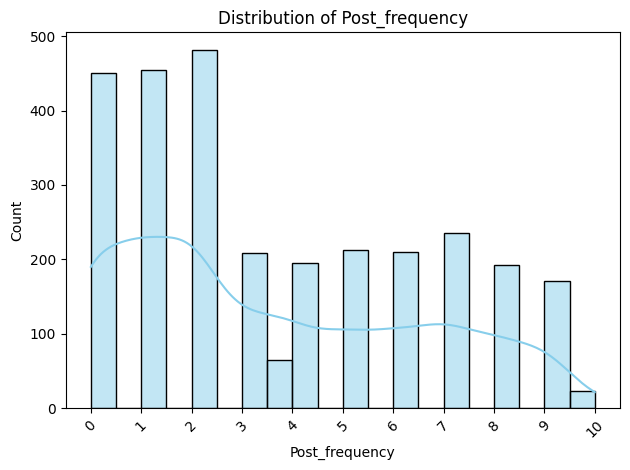

In [9]:
for col in df.columns[:-1]:
    if df[col].dtype == 'object':
        sns.countplot(data=df, x=col)
    else:
        sns.histplot(data=df, x=col, kde=True, bins=20, color='skyblue')
        plt.xticks(ticks=np.arange(df[col].min(), df[col].max()+1, step=1))
    
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


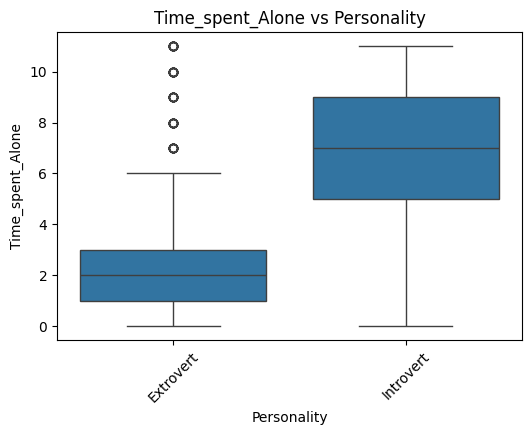

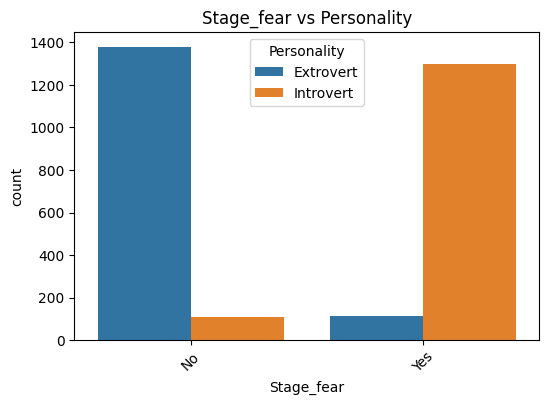

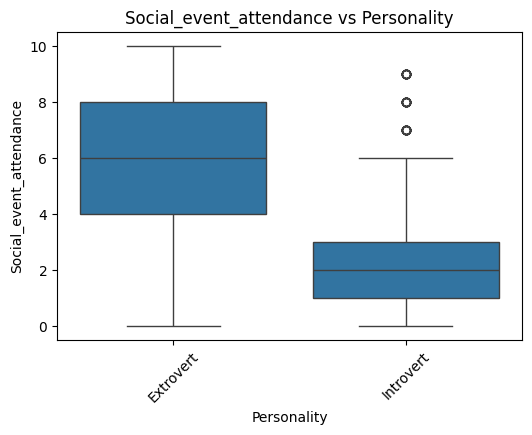

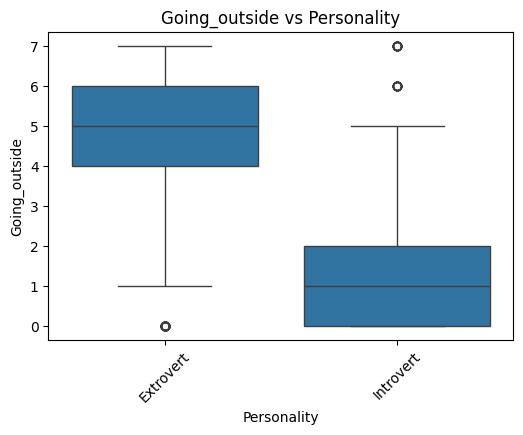

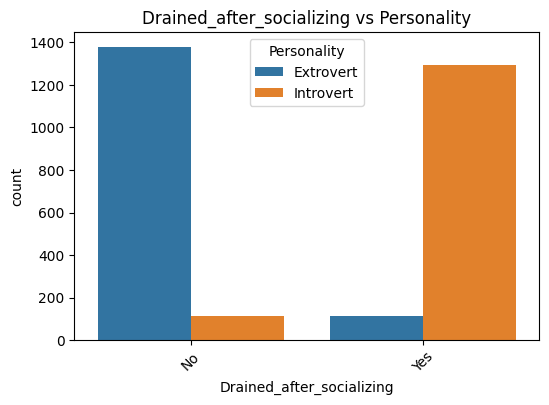

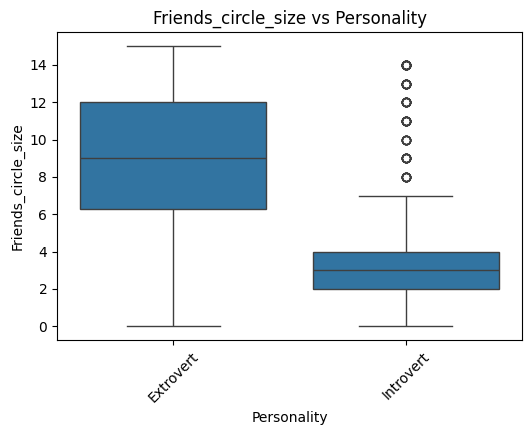

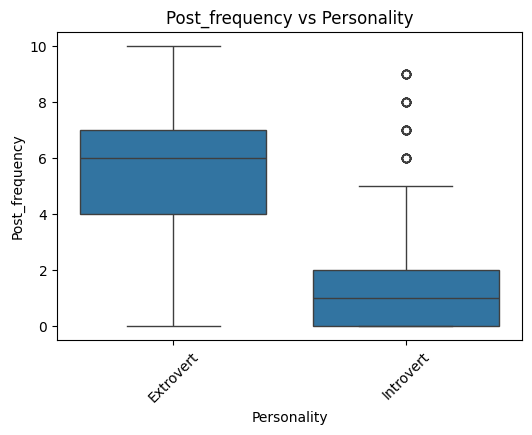

In [10]:
for col in df.columns[:-1]:
    plt.figure(figsize=(6, 4))
    if df[col].dtype == 'object':
        sns.countplot(data=df, x=col, hue='Personality')
    else:
        sns.boxplot(data=df, x='Personality', y=col)
    plt.title(f"{col} vs Personality")
    plt.xticks(rotation=45)
    plt.show()


<Axes: >

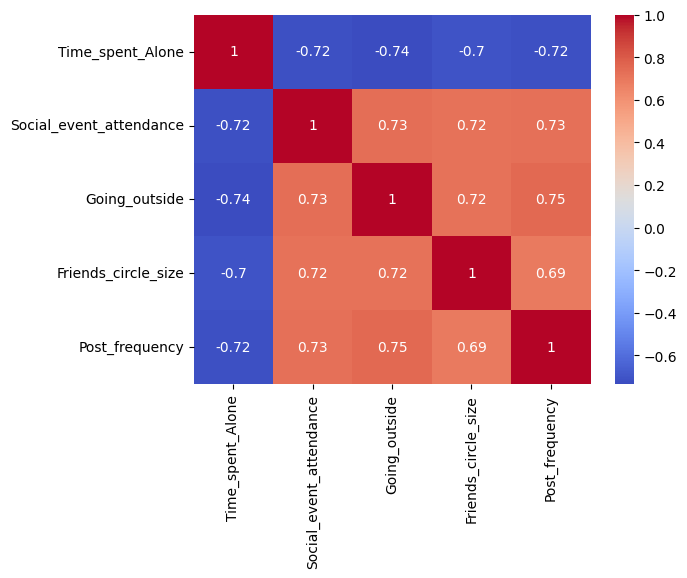

In [11]:
num_cols = df.select_dtypes(include='number')
sns.heatmap(num_cols.corr(), annot=True, cmap='coolwarm')

🔹 Z-Score Outliers in 'Time_spent_Alone': 0


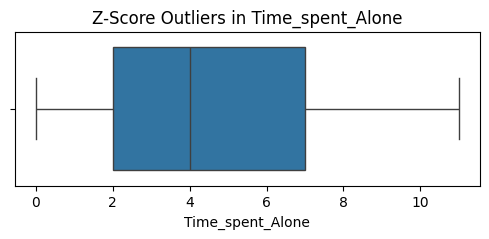

🔹 Z-Score Outliers in 'Social_event_attendance': 0


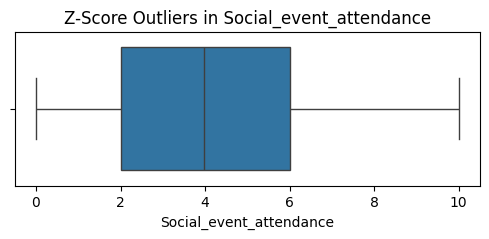

🔹 Z-Score Outliers in 'Going_outside': 0


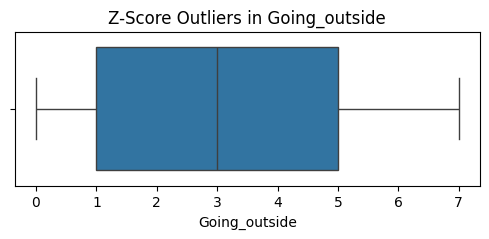

🔹 Z-Score Outliers in 'Friends_circle_size': 0


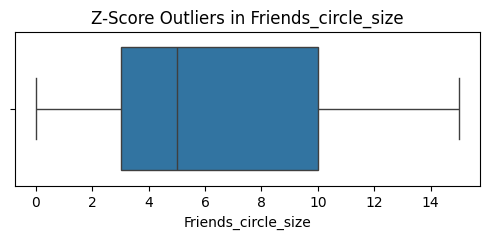

🔹 Z-Score Outliers in 'Post_frequency': 0


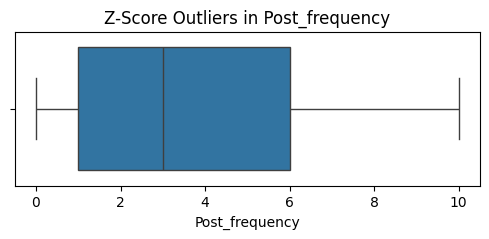

In [12]:
numeric_cols = df.select_dtypes(include=['number'])

for col in numeric_cols.columns:
    z_scores = stats.zscore(df[col])
    outliers = df[(abs(z_scores) > 3)]  

    print(f"🔹 Z-Score Outliers in '{col}': {outliers.shape[0]}")
    
    plt.figure(figsize=(6, 2))
    sns.boxplot(data=df, x=col)
    plt.title(f"Z-Score Outliers in {col}")
    plt.show()


In [13]:
X = df.drop('Personality', axis =1)
y = df['Personality']

In [14]:
X_encoded = X.copy()
for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X_encoded[col] = le.fit_transform(X[col])

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

In [16]:


param_grid = {
    'max_depth': range(1, 21)
}

grid = GridSearchCV(
    DecisionTreeClassifier(),
    param_grid,
    cv=5,             
    scoring='accuracy'
)

grid.fit(X_train, y_train)

print("Best Depth:", grid.best_params_['max_depth'])
print("Best Accuracy:", grid.best_score_)


Best Depth: 2
Best Accuracy: 0.935344827586207


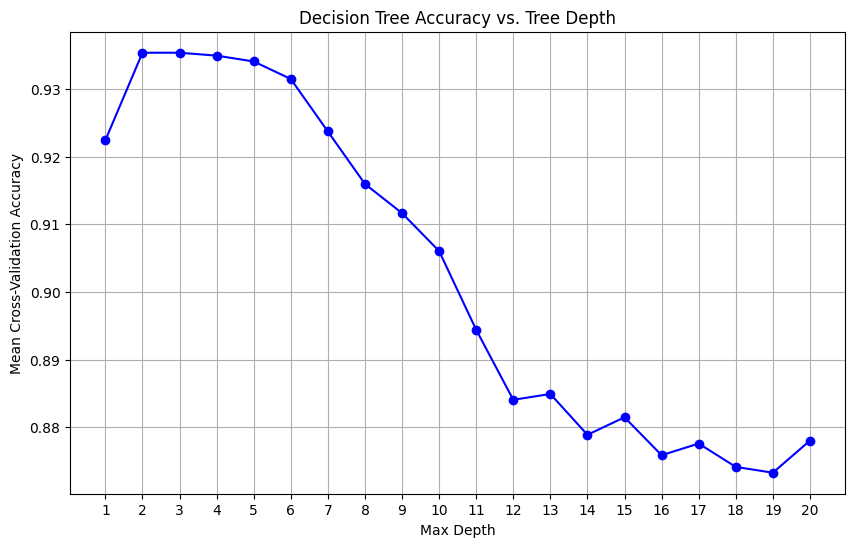

In [17]:
mean_scores = grid.cv_results_['mean_test_score']
depths = list(param_grid['max_depth'])

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(depths, mean_scores, marker='o', linestyle='-', color='blue')
plt.title('Decision Tree Accuracy vs. Tree Depth')
plt.xlabel('Max Depth')
plt.ylabel('Mean Cross-Validation Accuracy')
plt.grid(True)
plt.xticks(depths)
plt.show()

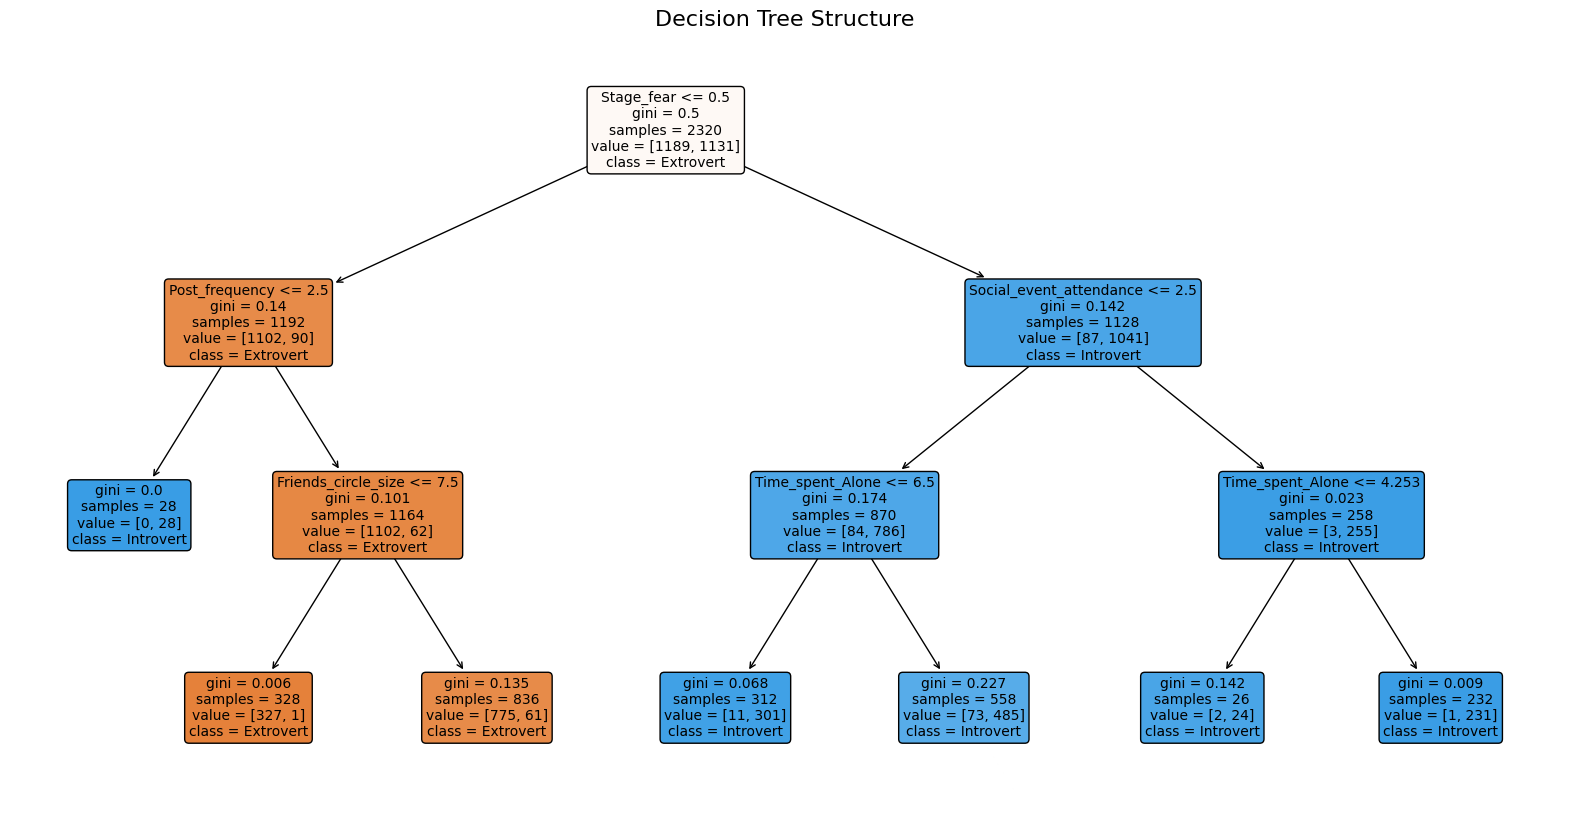

In [18]:
clf = DecisionTreeClassifier(max_depth = 3, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# 4. Draw Tree
plt.figure(figsize=(20, 10))  # Adjust size as needed
plot_tree(clf, 
          feature_names=X_encoded.columns, 
          class_names=[str(cls) for cls in set(y)], 
          filled=True, 
          rounded=True, 
          fontsize=10)
plt.title("Decision Tree Structure", fontsize=16)
plt.show()

Accuracy: 0.9293103448275862

Classification Report:
               precision    recall  f1-score   support

   Extrovert       0.94      0.92      0.93       302
   Introvert       0.92      0.94      0.93       278

    accuracy                           0.93       580
   macro avg       0.93      0.93      0.93       580
weighted avg       0.93      0.93      0.93       580



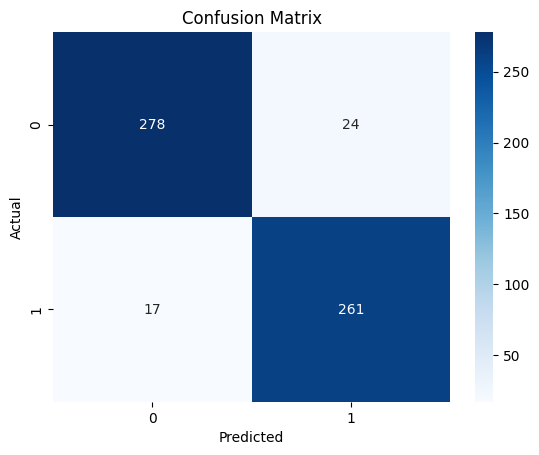

In [19]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

